In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
from selenium.webdriver.support.expected_conditions import none_of

plt.rcParams['font.family']='Times New Roman,Microsoft YaHei'# 设置字体族，中文为微软雅黑，英文为Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix' # 设置数%matplotlib qt学公式字体为stix
plt.style.use('seaborn-v0_8-paper')
# 设置全局参数
plt.rcParams['figure.facecolor'] = 'white'  # 设置图形的背景为透明
plt.rcParams['axes.facecolor'] = 'white'    # 设置轴域的背景为透明
plt.rcParams['savefig.facecolor'] = 'white' # 保存图像时背景透明
import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline
plt.rc("font", weight="bold")  # 全局字体设定
plt.rc("axes", labelweight="bold", titleweight="bold")  # 坐标轴标签 & 标题加粗
plt.rc("legend",  frameon=False)  # 图例字体大小 & 取消边框

In [2]:
import marsilea as ma
import marsilea.plotter as mp
from matplotlib.colors import Normalize
from sklearn.preprocessing import StandardScaler

In [3]:

dfmusic = pd.read_pickle("df_chordkey,pkl")
dfbird = pd.read_pickle('final_birds_df.pkl')
dfclasse = pd.read_pickle('final_classes_df.pkl')

In [4]:
dfbasic=pd.read_pickle("soundfeature_other.pkl")

In [5]:
dfbasic

,Date,place,level,ZCR,MEANt,VARt,SKEWt,KURTt,LEQt,BGNt,...,TFSD,H_Havrda,H_Renyi,H_pairedShannon,H_gamma,H_GiniSimpson,RAOQ,AGI,ROItotal,ROIcover
0,2023-09-23 22:30:00,CM,3,735.233333,-3.380577e-09,0.031529,-0.091968,7.297671,78.007665,-15.015999,...,0.604167,0.279415,0.910840,2.149657,1005.820882,0.643139,0.017437,1.551838,597,2.832839
1,2023-09-23 22:40:00,CM,3,700.300000,-8.018811e-09,0.012125,0.022089,5.315362,73.857293,-16.771927,...,0.606788,0.289758,1.017322,2.229338,1026.299671,0.673077,0.017052,1.456040,532,2.235284
2,2023-09-23 22:50:00,CM,3,749.466667,-7.088979e-09,0.022609,-0.119139,5.933532,76.563435,-14.865133,...,0.601843,0.283903,0.954286,2.217352,1016.967770,0.658005,0.017265,1.350232,533,2.116189
3,2023-09-23 23:00:00,CM,3,900.150000,1.304547e-08,0.048624,-0.093380,6.169316,79.889069,-12.823133,...,0.601574,0.285018,0.965698,2.231417,982.468184,0.663151,0.015753,1.512654,499,2.386366
4,2023-09-23 23:10:00,CM,3,1137.566667,-9.884437e-09,0.017953,-0.193201,7.784234,75.561962,-17.163616,...,0.602574,0.286803,0.984516,2.285993,1571.831123,0.667824,0.029282,1.530432,537,2.258154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606780,2023-09-23 21:40:00,CM,3,561.033333,-1.761119e-08,0.035154,-0.050709,5.469626,78.480411,-14.014729,...,0.603744,0.281082,0.926539,2.099177,497.190574,0.646241,0.006799,1.344388,287,2.057372
606781,2023-09-23 21:50:00,CM,3,900.266667,1.062751e-08,0.014750,-0.096056,8.769147,74.708562,-17.749647,...,0.601281,0.281851,0.933956,2.168922,1006.204960,0.649922,0.017237,1.315664,353,1.484406
606782,2023-09-23 22:00:00,CM,3,561.483333,-8.090337e-09,0.075675,-0.049162,4.603464,81.810160,-9.755486,...,0.600241,0.285247,0.968070,2.191768,642.327780,0.663092,0.008000,1.521721,420,2.819762
606783,2023-09-23 22:10:00,CM,3,1221.416667,-9.533267e-09,0.061232,-0.086586,7.823700,80.890388,-17.395420,...,0.606999,0.287222,0.989037,2.246934,861.277925,0.671032,0.012319,1.781269,460,4.504535


In [6]:
# 去除重复列
dfbasic = dfbasic.loc[:, ~dfbasic.columns.duplicated()]

# 定义高度替换规则
def replace_level(row):
    if row['place'] == 'ZS':
        return '3 m' if row['level'] == 1 else f"{row['level']}m"
    elif row['place'] == 'JH':
        return {1: '1.5 m', 2: '4 m', 3: '8 m', 4: '14 m'}.get(row['level'], f"{row['level']}m")
    elif row['place'] == 'CM':
        return {1: '1.5 m', 2: '10 m', 3: '16 m', 4: '22 m'}.get(row['level'], f"{row['level']}m")
    return f"{row['level']}m"

# 替换 level 列的值
dfbasic['level'] = dfbasic.apply(replace_level, axis=1)

In [7]:
df = pd.merge(dfmusic,dfclasse ,on=['Date', 'place', 'level'], how='inner')
df = pd.merge(df,dfbasic,on=['Date', 'place', 'level'], how='inner')

In [8]:
# 定义函数转换和弦到cents
def chord_to_cents(chord):
    note_cents = {
        'C': 0, 'C#': 100, 'D': 200, 'D#': 300, 'E': 400, 
        'F': 500, 'F#': 600, 'G': 700, 'G#': 800, 
        'A': 900, 'A#': 1000, 'B': 1100
    }
    # 分离根音和和弦类型
    root, chord_type = chord.split(':')
    root_cents = note_cents[root]
    # 大三和弦
    if chord_type == 'maj':
        return [root_cents, (root_cents + 400) % 1200, (root_cents + 700) % 1200]
    # 小三和弦
    elif chord_type == 'min':
        return [root_cents, (root_cents + 300) % 1200, (root_cents + 700) % 1200]
df['cents'] = df['event'].apply(chord_to_cents)

In [9]:
# 分类映射
category_mapping = {
    'Bird': ['Bird', 'Bird vocalization, bird call, bird song', 'Chirp, tweet', 'Duck', 'Fowl'],
    'Poultry': ['Duck', 'Fowl'],
    'Mammals': ['Rodents, rats, mice'],
    'Wild Animals': ['Frog','Animal', 'Wild animals'],
    'Environmental Sounds': ['White noise', 'Wind noise (microphone)','Rain', 'Rain on surface', 'Water', 'Wind'],
    'Insect': ['Insect'],
    'Transportation': ['Vehicle', 'Motorboat, speedboat', 'Boat, Water vehicle'],
    'Human Speech': ['Speech'],
    'Music and Instruments': ['Music', 'Synthesizer'],
    'Machinery and Tools': ['Camera', 'Single-lens reflex camera'],
}


# 将所有类别映射为 keyword -> category
keyword_to_category = {}
for category, keywords in category_mapping.items():
    for keyword in keywords:
        keyword_to_category[keyword] = category

# 优化后的分类函数
def classify_sound_class(sound_class):
    for keyword, category in keyword_to_category.items():
        if keyword in sound_class:
            return category
    return 'Other'  # 未匹配到的类别归为 'Other'


# 假设 df 是你的数据框
# 生成新列并进行分类
df['class'] = df['class'].apply(classify_sound_class)
# 按照 category_mapping 的顺序创建分类类型
category_order = list(category_mapping.keys())
# 将 'class_category' 列设置为分类类型，并指定排序顺序
df['class'] = pd.Categorical(df['class'], categories=category_order, ordered=True)
df = df.sort_values(by='class')

In [10]:
# 
# original_list = ['Vehicle', 'Animal', 'Wild animals', 'Music', 'Bird', 'Speech', 'Bird vocalization, bird call, bird song', 'Chirp, tweet', 'Camera', 'Single-lens reflex camera', 'White noise', 'Rodents, rats, mice', 'Fowl', 'Water', 'Insect', 'Synthesizer', 'Rain', 'Boat, Water vehicle', 'Duck', 'Frog', 'Motorboat, speedboat', 'Wind', 'Rain on surface', 'Wind noise (microphone)']
# 
# # 分类映射
# category_mapping = {
#     'Bird': ['Bird', 'Bird vocalization, bird call, bird song', 'Chirp, tweet', 'Duck', 'Fowl'],
#     'Poultry': ['Duck', 'Fowl'],
#     'Mammals': ['Rodents, rats, mice'],
#     'Other Wild Animals': ['Frog','Animal', 'Wild animals'],
#     'Insect': ['Insect'],
#     'Transportation': ['Vehicle', 'Motorboat, speedboat', 'Boat, Water vehicle'],
#     'Human Activities': ['Speech'],
#     'Music and Instruments': ['Music', 'Synthesizer'],
#     'Machinery and Tools': ['Camera', 'Single-lens reflex camera'],
#     'Environmental Sounds': ['White noise', 'Wind noise (microphone)'],
#     'Natural Phenomena': ['Rain', 'Rain on surface', 'Water', 'Wind']
# }
# 
# # 先提取 category_mapping 中所有的关键词
# classified_keywords = []
# for keywords in category_mapping.values():
#     classified_keywords.extend(keywords)
# 
# # 找出未被分类的项目
# unclassified = [item for item in original_list if item not in classified_keywords]
# 
# # 打印未分类的项目
# print("未被分类的项目有：", unclassified)

In [11]:
df

,sample,track,event,place,level,Date,class,ZCR,MEANt,VARt,...,H_Havrda,H_Renyi,H_pairedShannon,H_gamma,H_GiniSimpson,RAOQ,AGI,ROItotal,ROIcover,cents
605068,09:00,G minor,G:maj,ZS,3 m,2023-03-18 09:10:00,Bird,2181.450000,1.348207e-08,0.015339,...,0.325361,1.866591,3.942744,4583.870710,0.874652,0.142453,1.520395,323,10.269822,"[700, 1100, 200]"
487117,06:00,F# minor,G:maj,ZS,3 m,2024-03-16 06:00:00,Bird,1213.466667,7.663171e-09,0.009575,...,0.308670,1.301910,2.943426,1951.604287,0.764520,0.067133,1.457595,441,10.369119,"[700, 1100, 200]"
156301,07:00,D minor,G:maj,CM,10 m,2024-01-28 07:10:00,Bird,859.683333,-5.220374e-10,0.001451,...,0.312406,1.384044,3.018569,1523.237753,0.784555,0.027517,1.403170,552,9.854868,"[700, 1100, 200]"
156302,07:00,D minor,G:maj,CM,10 m,2024-01-28 07:10:00,Bird,859.683333,-5.220374e-10,0.001451,...,0.312406,1.384044,3.018569,1523.237753,0.784555,0.027517,1.403170,552,9.854868,"[700, 1100, 200]"
487115,06:00,F# minor,G:maj,ZS,3 m,2024-03-16 06:00:00,Bird,1213.466667,7.663171e-09,0.009575,...,0.308670,1.301910,2.943426,1951.604287,0.764520,0.067133,1.457595,441,10.369119,"[700, 1100, 200]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102758,18:30,G minor,G:maj,CM,10 m,2022-11-03 18:50:00,Machinery and Tools,499.833333,-3.897150e-09,0.001031,...,0.308940,1.307409,2.573860,724.956965,0.756288,0.006062,1.275119,332,1.211208,"[700, 1100, 200]"
1102757,18:30,G minor,G:maj,CM,10 m,2022-11-03 18:50:00,Machinery and Tools,499.833333,-3.897150e-09,0.001031,...,0.308940,1.307409,2.573860,724.956965,0.756288,0.006062,1.275119,332,1.211208,"[700, 1100, 200]"
1102756,18:30,G minor,G:maj,CM,10 m,2022-11-03 18:50:00,Machinery and Tools,499.833333,-3.897150e-09,0.001031,...,0.308940,1.307409,2.573860,724.956965,0.756288,0.006062,1.275119,332,1.211208,"[700, 1100, 200]"
387496,17:30,G major,G:maj,CM,16 m,2023-02-26 17:50:00,Machinery and Tools,132.850000,4.227956e-09,0.042996,...,0.267280,0.809341,1.892756,85.061127,0.598821,0.000270,1.358021,345,8.840743,"[700, 1100, 200]"


In [12]:
df.columns

Index(['sample', 'track', 'event', 'place', 'level', 'Date', 'class', 'ZCR',
       'MEANt', 'VARt', 'SKEWt', 'KURTt', 'LEQt', 'BGNt', 'SNRt', 'MED', 'Ht',
       'ACTtFraction', 'ACTtCount', 'ACTtMean', 'EVNtFraction', 'EVNtMean',
       'EVNtCount', 'MEANf', 'VARf', 'SKEWf', 'KURTf', 'NBPEAKS', 'LEQf',
       'ENRf', 'BGNf', 'SNRf', 'Hf', 'EAS', 'ECU', 'ECV', 'EPS', 'EPS_KURT',
       'EPS_SKEW', 'ACI', 'NDSI', 'rBA', 'AnthroEnergy', 'BioEnergy', 'BI',
       'ROU', 'ADI', 'AEI', 'LFC', 'MFC', 'HFC', 'ACTspFract', 'ACTspCount',
       'ACTspMean', 'EVNspFract', 'EVNspMean', 'EVNspCount', 'TFSD',
       'H_Havrda', 'H_Renyi', 'H_pairedShannon', 'H_gamma', 'H_GiniSimpson',
       'RAOQ', 'AGI', 'ROItotal', 'ROIcover', 'cents'],
      dtype='object')

In [13]:
# 提取根音和和弦类型
df['Root'] = df['event'].str.extract(r'([A-G]#?)')[0]
df['Quality'] = df['event'].str.extract(r':(\w+)')[0]
df['Major_Minor'] = df['Quality'].map({'maj': 'major', 'min': 'minor'})

In [14]:
print(list(df['class'].value_counts().index))

['Wild Animals', 'Transportation', 'Bird', 'Music and Instruments', 'Environmental Sounds', 'Human Speech', 'Machinery and Tools', 'Poultry', 'Mammals', 'Insect']


In [15]:
meanf_by_root = df.groupby('Root')['LEQf'].mean().sort_values()
sorted_root_order = meanf_by_root.index.tolist()
sorted_root_order

['G', 'C', 'G#', 'A#', 'D', 'F', 'C#', 'F#', 'A', 'D#', 'E', 'B']

In [16]:
# 1. 分别对 Major 和 Minor 按 Root 分组并计算 MEANf 的均值
meanf_major = df[df['Major_Minor'] == 'major'].groupby('Root')['MEANf'].mean().sort_values()
meanf_minor = df[df['Major_Minor'] == 'minor'].groupby('Root')['MEANf'].mean().sort_values()

# 2. 获取按照 MEANf 排序的 major 和 minor 的 root 顺序
sorted_major_root_order = meanf_major.index.tolist()
sorted_minor_root_order = meanf_minor.index.tolist()

In [17]:
# 分组计数
Nclass=20
grouped = df.groupby(['Root', 'Major_Minor', 'class'],observed=False).size().reset_index(name='Count')
top_classes = df['class'].value_counts().nlargest(Nclass).index
grouped['class'] = grouped['class'].apply(lambda x: x if x in top_classes else 'Others')
# 数据透视，准备绘图数据，增加Major_Minor区分
pivot_table = grouped.pivot_table(index=['Root', 'Major_Minor'], columns='class', values='Count', aggfunc='sum', fill_value=0,observed=False)
# 排序根音
root_order = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
df['Root'] = pd.Categorical(df['Root'], categories=root_order, ordered=True)
pivot_table = pivot_table.reindex(root_order, level=0)

In [18]:
# 归一化处理：将每个 Root 的 major 和 minor 和弦总数归一化为百分比
pivot_table_major = pivot_table.xs('major', level='Major_Minor')
pivot_table_minor = pivot_table.xs('minor', level='Major_Minor')

# 计算每个根音的总和
total_counts = pivot_table_major.sum(axis=1) + pivot_table_minor.sum(axis=1)

# 将major和minor分别归一化为百分比
pivot_table_major_pct = pivot_table_major.div(pivot_table_major.sum(axis=1), axis=0) * 100
pivot_table_minor_pct = pivot_table_minor.div(pivot_table_minor.sum(axis=1), axis=0) * 100

In [19]:
from palettable.tableau import Tableau_20
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
from brokenaxes import brokenaxes
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_colors = cmap(np.linspace(minval, maxval, n))
    new_cmap = LinearSegmentedColormap.from_list('trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval), new_colors)
    return new_cmap

C:\Users\aa271\AppData\Local\Temp\ipykernel_27840\1735229598.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_leqf_roots = df.copy().groupby('Root')['LEQf'].mean().nlargest(6).index


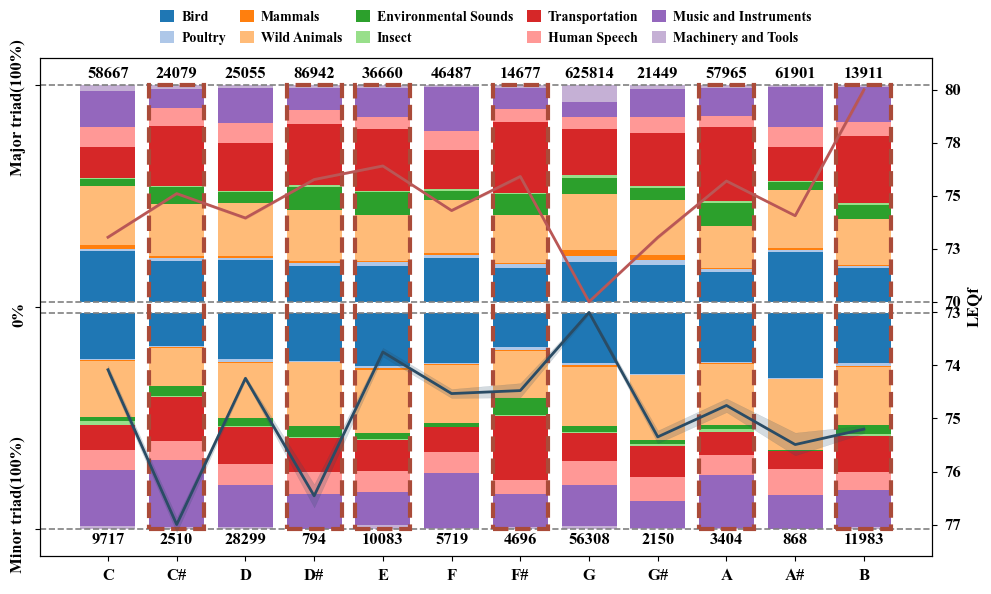

In [20]:
colors = np.array(Tableau_20.colors)/255
colors =mcolors.ListedColormap(colors)

# 设置绘图
fig, ax = plt.subplots(figsize=(10, 6))

# 空隙大小
y_gap = 5

# 存储已绘制的 class，以避免重复图例
drawn_classes = set()

# 遍历每个 class 进行堆叠绘制
for i, col in enumerate(pivot_table.columns):
    if col in pivot_table_major_pct.columns:
        # 绘制 major (正值)
        major_data = pivot_table_major_pct[col]
        label = f'{col}' if col not in drawn_classes else None
        bars_major = ax.bar(major_data.index, 
                            major_data, 
                            label=label, 
                            bottom=pivot_table_major_pct[pivot_table_major_pct.columns[:i]].sum(axis=1) + y_gap / 2,
                            color=colors(i), width=0.8)
        drawn_classes.add(col)

    if col in pivot_table_minor_pct.columns:
        # 绘制 minor (负值)
        minor_data = pivot_table_minor_pct[col]
        label = f'{col}' if col not in drawn_classes else None
        bars_minor = ax.bar(minor_data.index, 
                            -minor_data,  # 转为负值
                            label=label, 
                            bottom=-pivot_table_minor_pct[pivot_table_minor_pct.columns[:i]].sum(axis=1) - y_gap / 2,
                            color=colors(i), width=0.8)
        drawn_classes.add(col)

# 在bar的顶端标上总数（只标记总数）
for i, root in enumerate(pivot_table_major.index):
    total_major = pivot_table_major.loc[root].sum()
    total_minor = pivot_table_minor.loc[root].sum()
    
    # 标注 major 部分的总数
    ax.text(i, 104, f'{int(total_major)}', ha='center', va='bottom', fontsize=12)
    
    # 标注 minor 部分的总数
    ax.text(i, -104, f'{int(total_minor)}', ha='center', va='top', fontsize=12)

# 添加标签和标题
# ax.set_xlabel('Pitch Class')
# ax.set_ylabel('Percentage')
ax.set_yticks([-100-y_gap/2, 0, 100+y_gap/2])
ax.set_yticklabels(['', '0%', ''],rotation=90,fontsize=12)
# 添加 'Minor triad(100%)' 标签并向下移动
ax.text(-1.2, -91, 'Minor triad(100%)', va='center', ha='right', fontsize=12, rotation=90)
# 添加 'Major triad(100%)' 标签并向上移动
ax.text(-1.2, 92, 'Major triad(100%)', va='center', ha='right', fontsize=12, rotation=90)
ax.set_ylim([-115, 115])
ax.tick_params(axis='x', labelsize=13)


# 添加 y=0 的水平线
ax.axhline(y_gap/2, color='grey', linewidth=1.2,linestyle='--')
ax.axhline(-y_gap/2, color='grey', linewidth=1.2,linestyle='--')
ax.axhline(100+y_gap/2, color='grey', linewidth=1.2,linestyle='--')
ax.axhline(-100-y_gap/2, color='grey', linewidth=1.2,linestyle='--')


# 创建右侧的y轴
ax2 = ax.twinx()
# 分离 major 和 minor 数据
major_data = df.copy()[df['Major_Minor'] == 'major']
minor_data = df.copy()[df['Major_Minor'] == 'minor']
# 分别获取每个分组的 LEQf 均值，区分 Major 和 Minor
grouped_leqf = df.groupby(['Root', 'Major_Minor'],observed=False)['LEQf'].mean()
# 获取 Major 和 Minor 的最小值和最大值
leqf_min_major = grouped_leqf.xs('major', level='Major_Minor').min()
leqf_max_major = grouped_leqf.xs('major', level='Major_Minor').max()
leqf_min_minor = grouped_leqf.xs('minor', level='Major_Minor').min()
leqf_max_minor = grouped_leqf.xs('minor', level='Major_Minor').max()

# 分别归一化 Major 和 Minor 的 LEQf 数据，范围在 0-100
major_data['LEQf_normalized'] = (major_data['LEQf'] - leqf_min_major) / (leqf_max_major - leqf_min_major) * 100 + y_gap/2
minor_data['LEQf_normalized'] = -((minor_data['LEQf'] - leqf_min_minor) / (leqf_max_minor - leqf_min_minor) * 100 + y_gap/2)
# 绘制 Major 的归一化 LEQf 数据，显示在正 y 轴上
sns.lineplot(x='Root', y='LEQf_normalized', data=major_data, color='#B95756', errorbar=("ci", 95), ax=ax2,linewidth=2)
# 绘制 Minor 的归一化 LEQf 数据，显示在负 y 轴上
sns.lineplot(x='Root', y='LEQf_normalized', data=minor_data, color='#2A4C65', errorbar=("ci", 95), ax=ax2,linewidth=2)


# 设置 y 轴范围，以0为中心
buffer = 15  # 增加的边距
y_range_major = 100 + buffer+y_gap/2
y_range_minor = 100 + buffer+y_gap/2
# 设置 y 轴范围，负轴为 Minor 的范围，正轴为 Major 的范围
ax2.set_ylim(-y_range_minor, y_range_major)
negative_ticks = np.linspace(-100-y_gap/2, -y_gap/2, 5)
positive_ticks = np.linspace(y_gap/2, 100+y_gap/2, 5)
# 合并负刻度、0 和正刻度，并添加 y_gap/2
ticks = np.concatenate([negative_ticks,  positive_ticks])
# 为每个刻度使用归一化到实际值的转换
minor_real_values = [leqf_min_minor + abs(tick) * (leqf_max_minor - leqf_min_minor) / 100 for tick in negative_ticks]
major_real_values = [leqf_min_major + tick * (leqf_max_major - leqf_min_major) / 100 for tick in positive_ticks]
# 添加 gap 处的实际值，即 minor 和 major 的最小值
gap_values = [leqf_min_minor, leqf_min_major]
# 设置 y 轴刻度
ax2.set_yticks(ticks)
# 设置 y 轴刻度标签，分别标出 Major 和 Minor 的最小和最大值，gap 处为最小值
ax2.set_yticklabels(
    [f'{int(real_value)}' for real_value in minor_real_values] + [f'{int(real_value)}' for real_value in major_real_values],
    fontsize=11
)
ax2.set_ylabel('LEQf', fontsize=12)

# 添加空隙，通过设置 bar 宽度小于 1 来增加空隙
for bar in bars_major:
    bar.set_width(0.8)
for bar in bars_minor:
    bar.set_width(0.8)
    
# 计算每个 Root 的平均 LEQf 值（也可以选择使用总值）
top_leqf_roots = df.copy().groupby('Root')['LEQf'].mean().nlargest(6).index

# 绘制带红色边框的 bar
for root in top_leqf_roots:
    ax.bar(
        root, 
        100+y_gap+100,  # 固定 bar 的高度为 100
        bottom=-100-y_gap/2, 
        color='none',  # 只画边框，不填充颜色
        edgecolor='#AA4B39',  # 添加红色边框
        linewidth=3, 
        width=0.8,zorder=100 , 
        linestyle='--'
    )


# 显示图例，移动到图的上方
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.11), ncol=5,fontsize=10,frameon=False)
ax.grid(False)


for axe in [ax,ax2]:
    for label in axe.get_xticklabels() + axe.get_yticklabels():
        label.set_fontweight('bold')
        label.set_color('black')  # 确保颜色为黑色
        label.set_fontsize(12)  # 确保颜色为黑色


# 显示图形
plt.tight_layout()
plt.savefig('声音种类与音高.svg', bbox_inches='tight', pad_inches=0.1)
plt.show()

C:\Users\aa271\AppData\Local\Temp\ipykernel_27840\1093576420.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_leqf_roots = df.copy().groupby('Root')['LEQf'].mean().nlargest(6).index


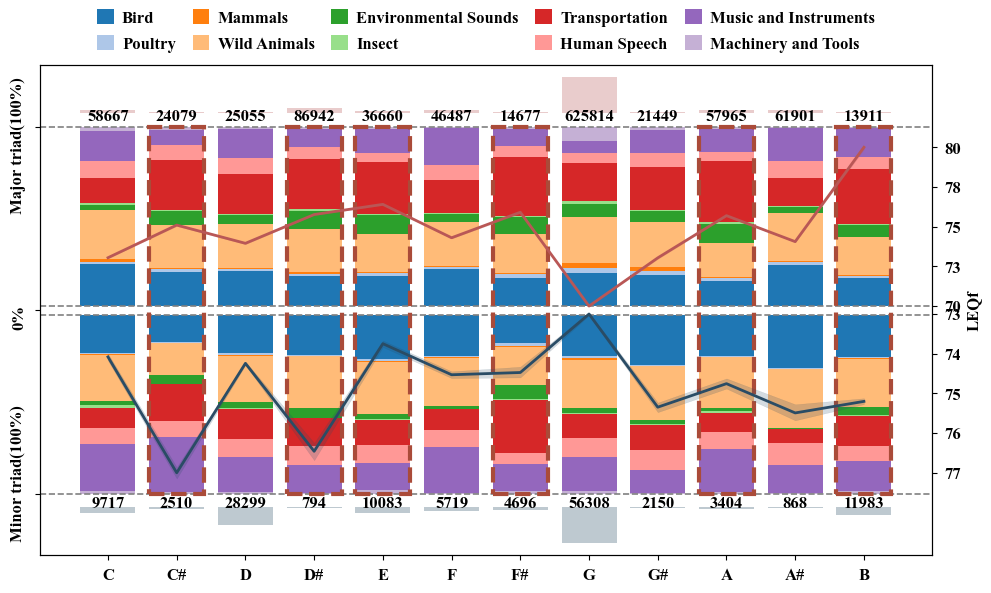

In [21]:
colors = np.array(Tableau_20.colors)/255
colors =mcolors.ListedColormap(colors)

# 设置绘图
fig, ax = plt.subplots(figsize=(10, 6))

# 空隙大小
y_gap = 5

# 存储已绘制的 class，以避免重复图例
drawn_classes = set()

# 遍历每个 class 进行堆叠绘制
for i, col in enumerate(pivot_table.columns):
    if col in pivot_table_major_pct.columns:
        # 绘制 major (正值)
        major_data = pivot_table_major_pct[col]
        label = f'{col}' if col not in drawn_classes else None
        bars_major = ax.bar(major_data.index, 
                            major_data, 
                            label=label, 
                            bottom=pivot_table_major_pct[pivot_table_major_pct.columns[:i]].sum(axis=1) + y_gap / 2,
                            color=colors(i), width=0.8)
        drawn_classes.add(col)

    if col in pivot_table_minor_pct.columns:
        # 绘制 minor (负值)
        minor_data = pivot_table_minor_pct[col]
        label = f'{col}' if col not in drawn_classes else None
        bars_minor = ax.bar(minor_data.index, 
                            -minor_data,  # 转为负值
                            label=label, 
                            bottom=-pivot_table_minor_pct[pivot_table_minor_pct.columns[:i]].sum(axis=1) - y_gap / 2,
                            color=colors(i), width=0.8)
        drawn_classes.add(col)

# 在bar的顶端标上总数（只标记总数）
for i, root in enumerate(pivot_table_major.index):
    total_major = pivot_table_major.loc[root].sum()
    total_minor = pivot_table_minor.loc[root].sum()
    
    # 标注 major 部分的总数
    ax.text(i, 104, f'{int(total_major)}', ha='center', va='bottom', fontsize=12)
    
    # 标注 minor 部分的总数
    ax.text(i, -104, f'{int(total_minor)}', ha='center', va='top', fontsize=12)

# 添加标签和标题
# ax.set_xlabel('Pitch Class')
# ax.set_ylabel('Percentage')
ax.set_yticks([-100-y_gap/2, 0, 100+y_gap/2])
ax.set_yticklabels(['', '0%', ''],rotation=90,fontsize=12)
# 添加 'Minor triad(100%)' 标签并向下移动
ax.text(-1.2, -91, 'Minor triad(100%)', va='center', ha='right', fontsize=12, rotation=90)
# 添加 'Major triad(100%)' 标签并向上移动
ax.text(-1.2, 92, 'Major triad(100%)', va='center', ha='right', fontsize=12, rotation=90)
ax.set_ylim([-137, 137])
ax.tick_params(axis='x', labelsize=13)


# 添加 y=0 的水平线
ax.axhline(y_gap/2, color='grey', linewidth=1.2,linestyle='--')
ax.axhline(-y_gap/2, color='grey', linewidth=1.2,linestyle='--')
ax.axhline(100+y_gap/2, color='grey', linewidth=1.2,linestyle='--')
ax.axhline(-100-y_gap/2, color='grey', linewidth=1.2,linestyle='--')


# 创建右侧的y轴
ax2 = ax.twinx()
# 分离 major 和 minor 数据
major_data = df.copy()[df['Major_Minor'] == 'major']
minor_data = df.copy()[df['Major_Minor'] == 'minor']
# 分别获取每个分组的 LEQf 均值，区分 Major 和 Minor
grouped_leqf = df.groupby(['Root', 'Major_Minor'],observed=False)['LEQf'].mean()
# 获取 Major 和 Minor 的最小值和最大值
leqf_min_major = grouped_leqf.xs('major', level='Major_Minor').min()
leqf_max_major = grouped_leqf.xs('major', level='Major_Minor').max()
leqf_min_minor = grouped_leqf.xs('minor', level='Major_Minor').min()
leqf_max_minor = grouped_leqf.xs('minor', level='Major_Minor').max()

# 分别归一化 Major 和 Minor 的 LEQf 数据，范围在 0-100
major_data['LEQf_normalized'] = (major_data['LEQf'] - leqf_min_major) / (leqf_max_major - leqf_min_major) * 100 + y_gap/2
minor_data['LEQf_normalized'] = -((minor_data['LEQf'] - leqf_min_minor) / (leqf_max_minor - leqf_min_minor) * 100 + y_gap/2)
# 绘制 Major 的归一化 LEQf 数据，显示在正 y 轴上
sns.lineplot(x='Root', y='LEQf_normalized', data=major_data, color='#B95756', errorbar=("ci", 95), ax=ax2,linewidth=2)
# 绘制 Minor 的归一化 LEQf 数据，显示在负 y 轴上
sns.lineplot(x='Root', y='LEQf_normalized', data=minor_data, color='#2A4C65', errorbar=("ci", 95), ax=ax2,linewidth=2)


# 设置 y 轴范围，以0为中心
buffer = 15  # 增加的边距
y_range_major = 137 + buffer+y_gap/2
y_range_minor = 137 + buffer+y_gap/2
# 设置 y 轴范围，负轴为 Minor 的范围，正轴为 Major 的范围
ax2.set_ylim(-y_range_minor, y_range_major)
negative_ticks = np.linspace(-100-y_gap/2, -y_gap/2, 5)
positive_ticks = np.linspace(y_gap/2, 100+y_gap/2, 5)
# 合并负刻度、0 和正刻度，并添加 y_gap/2
ticks = np.concatenate([negative_ticks,  positive_ticks])
# 为每个刻度使用归一化到实际值的转换
minor_real_values = [leqf_min_minor + abs(tick) * (leqf_max_minor - leqf_min_minor) / 100 for tick in negative_ticks]
major_real_values = [leqf_min_major + tick * (leqf_max_major - leqf_min_major) / 100 for tick in positive_ticks]
# 添加 gap 处的实际值，即 minor 和 major 的最小值
gap_values = [leqf_min_minor, leqf_min_major]
# 设置 y 轴刻度
ax2.set_yticks(ticks)
# 设置 y 轴刻度标签，分别标出 Major 和 Minor 的最小和最大值，gap 处为最小值
ax2.set_yticklabels(
    [f'{int(real_value)}' for real_value in minor_real_values] + [f'{int(real_value)}' for real_value in major_real_values],
    fontsize=11
)
ax2.set_ylabel('LEQf', fontsize=12)

# 添加空隙，通过设置 bar 宽度小于 1 来增加空隙
for bar in bars_major:
    bar.set_width(0.8)
for bar in bars_minor:
    bar.set_width(0.8)
    
# 计算每个 Root 的平均 LEQf 值（也可以选择使用总值）
top_leqf_roots = df.copy().groupby('Root')['LEQf'].mean().nlargest(6).index

# 绘制带红色边框的 bar
for root in top_leqf_roots:
    ax.bar(
        root, 
        100+y_gap+100,  # 固定 bar 的高度为 100
        bottom=-100-y_gap/2, 
        color='none',  # 只画边框，不填充颜色
        edgecolor='#AA4B39',  # 添加红色边框
        linewidth=3, 
        width=0.8,zorder=100 , 
        linestyle='--'
    )

max_count_major = pivot_table_major.sum(axis=1).max()  # major 类别的最大 count
max_count_minor = pivot_table_minor.sum(axis=1).max()  # minor 类别的最大 count
# 对 major 和 minor 进行归一化，使其在 0-20 范围内
normalized_count_major = (pivot_table_major.sum(axis=1) / max_count_major) * 20
normalized_count_minor = (pivot_table_minor.sum(axis=1) / max_count_minor) * 20
# 绘制 major 的新条形图
bars_count_major = ax.bar(pivot_table_major.index, 
                          normalized_count_major,  # 归一化后的高度
                          bottom=110,  # 让其位于现有 major 条形图的上方
                          color='#B95756', alpha=0.3)
# 绘制 minor 的新条形图
bars_count_minor = ax.bar(pivot_table_minor.index, 
                          -normalized_count_minor,  # 归一化后的高度为负值
                          bottom=-110,  # 让其位于现有 minor 条形图的下方
                          color='#2A4C65', alpha=0.3)


# 显示图例，移动到图的上方
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=5,fontsize=12,frameon=False)
ax.grid(False)


for axe in [ax,ax2]:
    for label in axe.get_xticklabels() + axe.get_yticklabels():
        label.set_fontweight('bold')
        label.set_color('black')  # 确保颜色为黑色
        label.set_fontsize(12)  # 确保颜色为黑色


# 显示图形
plt.tight_layout()
plt.savefig('声音种类与音高.svg', bbox_inches='tight', pad_inches=0.1)
plt.show()

In [22]:
df = pd.merge(dfmusic,dfbird ,on=['Date', 'place', 'level'], how='inner')
df = pd.merge(df,dfbasic,on=['Date', 'place', 'level'], how='inner')

In [23]:
# 提取根音和和弦类型
df['Root'] = df['event'].str.extract(r'([A-G]#?)')[0]
df['Quality'] = df['event'].str.extract(r':(\w+)')[0]
df['Major_Minor'] = df['Quality'].map({'maj': 'major', 'min': 'minor'})
meanf_by_root = df.groupby('Root')['LEQf'].mean().sort_values()
sorted_root_order = meanf_by_root.index.tolist()
sorted_root_order

['G', 'C', 'G#', 'A#', 'D', 'F', 'F#', 'C#', 'A', 'E', 'D#', 'B']

In [24]:
# 1. 分别对 Major 和 Minor 按 Root 分组并计算 MEANf 的均值
meanf_major = df[df['Major_Minor'] == 'major'].groupby('Root')['MEANf'].mean().sort_values()
meanf_minor = df[df['Major_Minor'] == 'minor'].groupby('Root')['MEANf'].mean().sort_values()

# 2. 获取按照 MEANf 排序的 major 和 minor 的 root 顺序
sorted_major_root_order = meanf_major.index.tolist()
sorted_minor_root_order = meanf_minor.index.tolist()
# 分组计数
Nclass = 9
grouped = df.groupby(['Root', 'Major_Minor', 'bird'], observed=False).size().reset_index(name='Count')
top_classes = df['bird'].value_counts().nlargest(Nclass).index
grouped['bird'] = grouped['bird'].apply(lambda x: x if x in top_classes else 'Others')
# 数据透视，准备绘图数据，增加Major_Minor区分
pivot_table = grouped.pivot_table(index=['Root', 'Major_Minor'], columns='bird', values='Count', aggfunc='sum',
                                  fill_value=0, observed=False)
# 排序根音
root_order = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
df['Root'] = pd.Categorical(df['Root'], categories=root_order, ordered=True)
pivot_table = pivot_table.reindex(root_order, level=0)
# 归一化处理：将每个 Root 的 major 和 minor 和弦总数归一化为百分比
pivot_table_major = pivot_table.xs('major', level='Major_Minor')
pivot_table_minor = pivot_table.xs('minor', level='Major_Minor')

# 计算每个根音的总和
total_counts = pivot_table_major.sum(axis=1) + pivot_table_minor.sum(axis=1)

# 将major和minor分别归一化为百分比
pivot_table_major_pct = pivot_table_major.div(pivot_table_major.sum(axis=1), axis=0) * 100
pivot_table_minor_pct = pivot_table_minor.div(pivot_table_minor.sum(axis=1), axis=0) * 100
from palettable.tableau import Tableau_20
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
from brokenaxes import brokenaxes


def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_colors = cmap(np.linspace(minval, maxval, n))
    new_cmap = LinearSegmentedColormap.from_list('trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
                                                 new_colors)
    return new_cmap

C:\Users\aa271\AppData\Local\Temp\ipykernel_27840\2537362201.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_leqf_roots = df.copy().groupby('Root')['ADI'].mean().nlargest(6).index


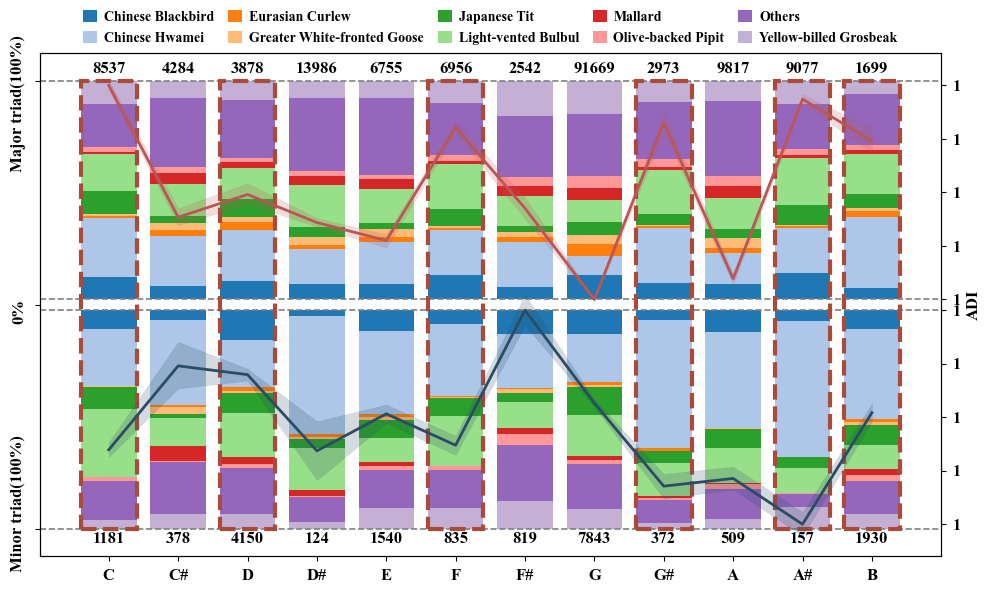

In [25]:
colors = np.array(Tableau_20.colors)/255
colors =mcolors.ListedColormap(colors)

# 设置绘图
fig, ax = plt.subplots(figsize=(10, 6))

# 空隙大小
y_gap = 5

# 存储已绘制的 class，以避免重复图例
drawn_classes = set()

# 遍历每个 class 进行堆叠绘制
for i, col in enumerate(pivot_table.columns):
    if col in pivot_table_major_pct.columns:
        # 绘制 major (正值)
        major_data = pivot_table_major_pct[col]
        label = f'{col}' if col not in drawn_classes else None
        bars_major = ax.bar(major_data.index, 
                            major_data, 
                            label=label, 
                            bottom=pivot_table_major_pct[pivot_table_major_pct.columns[:i]].sum(axis=1) + y_gap / 2,
                            color=colors(i), width=0.8)
        drawn_classes.add(col)

    if col in pivot_table_minor_pct.columns:
        # 绘制 minor (负值)
        minor_data = pivot_table_minor_pct[col]
        label = f'{col}' if col not in drawn_classes else None
        bars_minor = ax.bar(minor_data.index, 
                            -minor_data,  # 转为负值
                            label=label, 
                            bottom=-pivot_table_minor_pct[pivot_table_minor_pct.columns[:i]].sum(axis=1) - y_gap / 2,
                            color=colors(i), width=0.8)
        drawn_classes.add(col)

# 在bar的顶端标上总数（只标记总数）
for i, root in enumerate(pivot_table_major.index):
    total_major = pivot_table_major.loc[root].sum()
    total_minor = pivot_table_minor.loc[root].sum()
    
    # 标注 major 部分的总数
    ax.text(i, 104, f'{int(total_major)}', ha='center', va='bottom', fontsize=12)
    
    # 标注 minor 部分的总数
    ax.text(i, -104, f'{int(total_minor)}', ha='center', va='top', fontsize=12)

# 添加标签和标题
# ax.set_xlabel('Pitch Class')
# ax.set_ylabel('Percentage')
ax.set_yticks([-100-y_gap/2, 0, 100+y_gap/2])
ax.set_yticklabels(['', '0%', ''],rotation=90,fontsize=12)
# 添加 'Minor triad(100%)' 标签并向下移动
ax.text(-1.2, -91, 'Minor triad(100%)', va='center', ha='right', fontsize=12, rotation=90)
# 添加 'Major triad(100%)' 标签并向上移动
ax.text(-1.2, 92, 'Major triad(100%)', va='center', ha='right', fontsize=12, rotation=90)
ax.set_ylim([-115, 115])
ax.tick_params(axis='x', labelsize=13)


# 添加 y=0 的水平线
ax.axhline(y_gap/2, color='grey', linewidth=1.2,linestyle='--')
ax.axhline(-y_gap/2, color='grey', linewidth=1.2,linestyle='--')
ax.axhline(100+y_gap/2, color='grey', linewidth=1.2,linestyle='--')
ax.axhline(-100-y_gap/2, color='grey', linewidth=1.2,linestyle='--')


# 创建右侧的y轴
ax2 = ax.twinx()
# 分离 major 和 minor 数据
major_data = df.copy()[df['Major_Minor'] == 'major']
minor_data = df.copy()[df['Major_Minor'] == 'minor']
# 分别获取每个分组的 LEQf 均值，区分 Major 和 Minor
grouped_leqf = df.groupby(['Root', 'Major_Minor'],observed=False)['ADI'].mean()
# 获取 Major 和 Minor 的最小值和最大值
leqf_min_major = grouped_leqf.xs('major', level='Major_Minor').min()
leqf_max_major = grouped_leqf.xs('major', level='Major_Minor').max()
leqf_min_minor = grouped_leqf.xs('minor', level='Major_Minor').min()
leqf_max_minor = grouped_leqf.xs('minor', level='Major_Minor').max()

# 分别归一化 Major 和 Minor 的 LEQf 数据，范围在 0-100
major_data['LEQf_normalized'] = (major_data['ADI'] - leqf_min_major) / (leqf_max_major - leqf_min_major) * 100 + y_gap/2
minor_data['LEQf_normalized'] = -((minor_data['ADI'] - leqf_min_minor) / (leqf_max_minor - leqf_min_minor) * 100 + y_gap/2)
# 绘制 Major 的归一化 LEQf 数据，显示在正 y 轴上
sns.lineplot(x='Root', y='LEQf_normalized', data=major_data, color='#B95756', errorbar=("ci", 95), ax=ax2,linewidth=2)
# 绘制 Minor 的归一化 LEQf 数据，显示在负 y 轴上
sns.lineplot(x='Root', y='LEQf_normalized', data=minor_data, color='#2A4C65', errorbar=("ci", 95), ax=ax2,linewidth=2)


# 设置 y 轴范围，以0为中心
buffer = 15  # 增加的边距
y_range_major = 100 + buffer+y_gap/2
y_range_minor = 100 + buffer+y_gap/2
# 设置 y 轴范围，负轴为 Minor 的范围，正轴为 Major 的范围
ax2.set_ylim(-y_range_minor, y_range_major)
negative_ticks = np.linspace(-100-y_gap/2, -y_gap/2, 5)
positive_ticks = np.linspace(y_gap/2, 100+y_gap/2, 5)
# 合并负刻度、0 和正刻度，并添加 y_gap/2
ticks = np.concatenate([negative_ticks,  positive_ticks])
# 为每个刻度使用归一化到实际值的转换
minor_real_values = [leqf_min_minor + abs(tick) * (leqf_max_minor - leqf_min_minor) / 100 for tick in negative_ticks]
major_real_values = [leqf_min_major + tick * (leqf_max_major - leqf_min_major) / 100 for tick in positive_ticks]
# 添加 gap 处的实际值，即 minor 和 major 的最小值
gap_values = [leqf_min_minor, leqf_min_major]
# 设置 y 轴刻度
ax2.set_yticks(ticks)
# 设置 y 轴刻度标签，分别标出 Major 和 Minor 的最小和最大值，gap 处为最小值
ax2.set_yticklabels(
    [f'{int(real_value)}' for real_value in minor_real_values] + [f'{int(real_value)}' for real_value in major_real_values],
    fontsize=11
)
ax2.set_ylabel('ADI', fontsize=12)

# 添加空隙，通过设置 bar 宽度小于 1 来增加空隙
for bar in bars_major:
    bar.set_width(0.8)
for bar in bars_minor:
    bar.set_width(0.8)
    
# 计算每个 Root 的平均 LEQf 值（也可以选择使用总值）
top_leqf_roots = df.copy().groupby('Root')['ADI'].mean().nlargest(6).index

# 绘制带红色边框的 bar
for root in top_leqf_roots:
    ax.bar(
        root, 
        100+y_gap+100,  # 固定 bar 的高度为 100
        bottom=-100-y_gap/2, 
        color='none',  # 只画边框，不填充颜色
        edgecolor='#AA4B39',  # 添加红色边框
        linewidth=3, 
        width=0.8,zorder=100 , 
        linestyle='--'
    )

for axe in [ax,ax2]:
    for label in axe.get_xticklabels() + axe.get_yticklabels():
        label.set_fontweight('bold')
        label.set_color('black')  # 确保颜色为黑色
        label.set_fontsize(12)  # 确保颜色为黑色


# 显示图例，移动到图的上方
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=5,fontsize=10,frameon=False)
ax.grid(False)
# 显示图形
plt.tight_layout()
plt.savefig('声音种类与鸟类.svg', bbox_inches='tight', pad_inches=0.1)
plt.show()